In [1]:
# python 3.12.12
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# pip install seaborn
# pip install scikit-learn

from run import *

In [2]:
df = pd.read_parquet('./data/df_260315.parquet',engine='fastparquet')
print(df.shape)
print(df.head())

(139924, 12)
      Open     High      Low    Close      Volume              Close time  \
0  0.04968  0.05140  0.04949  0.05094  53823.8559 2024-05-01 23:59:59.999   
1  0.05094  0.05161  0.05037  0.05055  31896.3678 2024-05-02 23:59:59.999   
2  0.05055  0.05078  0.04925  0.04934  31633.2277 2024-05-03 23:59:59.999   
3  0.04934  0.04970  0.04875  0.04879  18054.0630 2024-05-04 23:59:59.999   
4  0.04879  0.04965  0.04858  0.04899  16878.6574 2024-05-05 23:59:59.999   

  Quote asset volume  Number of trades Taker buy base asset volume  \
0      2715.82238206            177665              27896.64200000   
1      1621.28357957            107466              15688.28470000   
2      1579.95833005            113175              14428.12320000   
3       888.11955777             83140               9011.75720000   
4       828.16583151             64357               8558.99060000   

  Taker buy quote asset volume Ignore  Symbol  
0                1407.21806973      0  ETHBTC  
1      

In [ ]:
outdir = "./output/" + datetime.now().strftime('%y%m%d%H%M%S') + "/"
os.mkdir(outdir)

fit_and_out(df=df, target='Close', outdir=outdir)

Train set - x_past: (48257, 30, 9), x_static: (48257, 1)
Valid set - x_past: (6727, 30, 9), x_static: (6727, 1)
Test set - x_past: (64032, 30, 9), x_static: (64032, 1)
=======1. TFT 모델 학습중=======
[epoch 001] val_loss=0.069740 | ts_loss =0.771002 lr=1.00e-03
  -> saved best to ./output/260316213826/Close_tft_test_260312.pt


====================output building 중====================


c:\Users\rbs\Dropbox\101.대학원생활\1학년2학기\04_노알버트_첨단컴퓨팅세미나_목1\GCY6901\run.py:263: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')


Chart saved at: ./output/260315235630/Close_comparison_summary.png


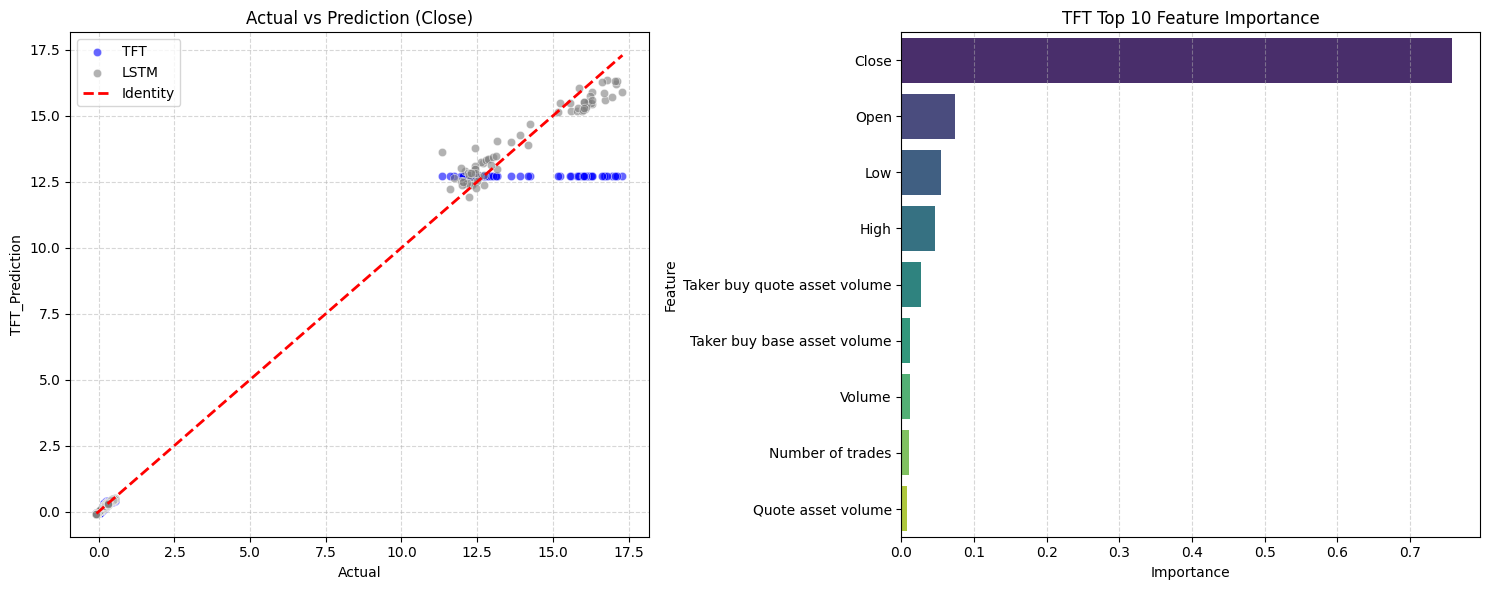

In [ ]:
past_outdir = "./output/260315235630/" 
load_and_output(
    df=df,
    tft_path=past_outdir + "Close_tft_test_260312.pt",
    lstm_path=past_outdir + "Close_lstm_test_260312.pt",
    target='Close',
    outdir=past_outdir,
    seq_length=30 # 현재 30일짜리임.
)